In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

In [2]:
def TrinomialProbs(r, q, sigma, deltaT, lambda_val=np.sqrt(3)):
    """
    Calculate trinomial tree probabilities using optimal lambda for kurtosis matching
    Solves: 1) Mean matching, 2) Variance matching, 3) Probabilities sum to 1
    """
    nu = r - q - 0.5 * sigma**2
    deltaX = lambda_val * sigma * np.sqrt(deltaT)

    # System of equations solution
    V = sigma**2 * deltaT + nu**2 * deltaT**2

    p_u = 0.5 * (V / deltaX**2 + nu * deltaT / deltaX)
    p_d = 0.5 * (V / deltaX**2 - nu * deltaT / deltaX)
    p_m = 1 - p_u - p_d

    return p_u, p_m, p_d, deltaX, lambda_val

In [3]:
S0 = 60
K_call = 55
K_put = 65
r = 0.03
q = 0.05
T = 1.0
sigma_values = [0.2, 0.3, 0.4, 0.5]
n_values = [2**11, 2**12, 2**13]

In [4]:
def american_call_boundary(S0, K, r, q, sigma, T, N):
    deltaT = T / N
    p_u, p_m, p_d, deltaX, lam = TrinomialProbs(r, q, sigma, deltaT)
    discount = np.exp(-r * deltaT)

    # Set up S values (at maturity)
    Svals = S0 * np.exp(np.arange(N, -N-1, -1) * deltaX)

    # Set up lattice and terminal values
    Cvals = np.zeros((2 * N + 1, N + 1))
    Cvals[:, N] = np.maximum(Svals - K, 0)

    # Backward induction vectorized
    for j in range(N - 1, -1, -1):
        i_vals = np.arange(N - j, N + j + 1)
        hold = discount * (p_u * Cvals[i_vals - 1, j + 1] +
                           p_m * Cvals[i_vals, j + 1] +
                           p_d * Cvals[i_vals + 1, j + 1])
        Cvals[i_vals, j] = np.maximum(Svals[i_vals] - K, hold)

    # Compute exercise boundary vectorized
    boundary = np.full(N, np.nan)
    for j in range(N - 1, -1, -1):
        i_vals = np.arange(N - j, N + j + 1)
        mask = (Cvals[i_vals, j] == Svals[i_vals] - K)
        if np.any(mask):
            boundary[j] = np.min(Svals[i_vals][mask])  # min for call

    return (T, boundary)

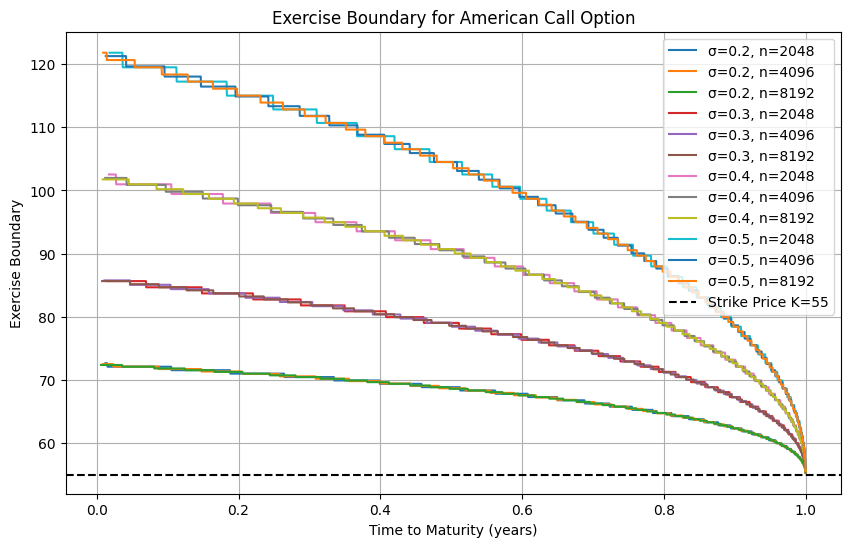

In [5]:
# Generate exercise boundary for different values of sigma and n
exercise_boundary_call = {}
for sigma in sigma_values:
    for n in n_values:
        exercise_boundary_call[(sigma, n)] = american_call_boundary(S0, K_call, r, q, sigma, T, n)

# Plotting the exercise boundary
plt.figure(figsize=(10, 6))
for sigma in sigma_values:
    for n in n_values:
        n1, prices = exercise_boundary_call[(sigma, n)]
        deltaT = T / n
        times_from_now = np.arange(0, n) * deltaT
        plt.plot(times_from_now, prices, label=f"σ={sigma}, n={n}")
plt.axhline(y=K_call, linestyle='--', color='k', label='Strike Price K=55')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Exercise Boundary')
plt.title('Exercise Boundary for American Call Option')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def american_put_boundary(S0, K, r, q, sigma, T, N):
    deltaT = T / N
    p_u, p_m, p_d, deltaX, lam = TrinomialProbs(r, q, sigma, deltaT)
    discount = np.exp(-r * deltaT)

    # Set up S values (at maturity)
    Svals = S0 * np.exp(np.arange(N, -N-1, -1) * deltaX)

    # Set up lattice and terminal values
    Pvals = np.zeros((2 * N + 1, N + 1))
    Pvals[:, N] = np.maximum(K - Svals, 0)

    # Backward induction vectorized
    for j in range(N - 1, -1, -1):
        i_vals = np.arange(N - j, N + j + 1)
        hold = discount * (p_u * Pvals[i_vals - 1, j + 1] +
                           p_m * Pvals[i_vals, j + 1] +
                           p_d * Pvals[i_vals + 1, j + 1])
        Pvals[i_vals, j] = np.maximum(K - Svals[i_vals], hold)

    # Compute exercise boundary vectorized
    boundary = np.full(N, np.nan)
    for j in range(N - 1, -1, -1):
        i_vals = np.arange(N - j, N + j + 1)
        mask = (Pvals[i_vals, j] == K - Svals[i_vals])
        if np.any(mask):
            boundary[j] = np.max(Svals[i_vals][mask])  # max for put

    return (T, boundary)

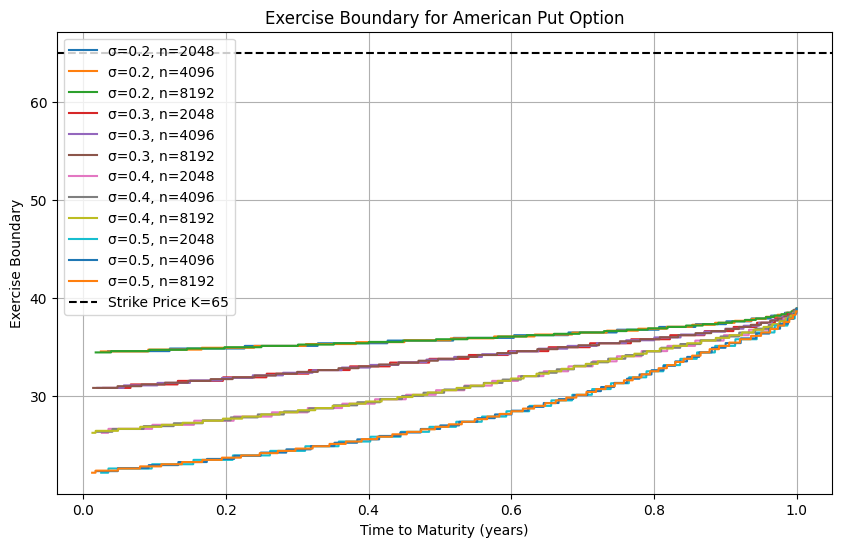

In [9]:
# Generate exercise boundary for different values of sigma and n
exercise_boundary_put = {}
for sigma in sigma_values:
    for n in n_values:
        exercise_boundary_put[(sigma, n)] = american_put_boundary(S0, K_put, r, q, sigma, T, n)

# Plotting the exercise boundary
plt.figure(figsize=(10, 6))
for sigma in sigma_values:
    for n in n_values:
        n1, prices = exercise_boundary_put[(sigma, n)]
        deltaT = T / n
        times_from_now = np.arange(0, n) * deltaT
        plt.plot(times_from_now, prices, label=f"σ={sigma}, n={n}")
plt.axhline(y=K_put, linestyle='--', color='k', label='Strike Price K=65')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Exercise Boundary')
plt.title('Exercise Boundary for American Put Option')
plt.legend()
plt.grid(True)
plt.show()